# Multiple Regression - California Housing Dataset

This is a personal project just for me to learn how to implement multiple regression from scratch. I will use numpy arrays to do this.

## Exploratory Data Analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
%matplotlib inline

In [14]:
housing_data = pd.read_csv('./housing.csv')
housing_data.dropna(axis='index', inplace=True)

housing_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [3]:
housing_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
housing_data.shape

(20640, 10)

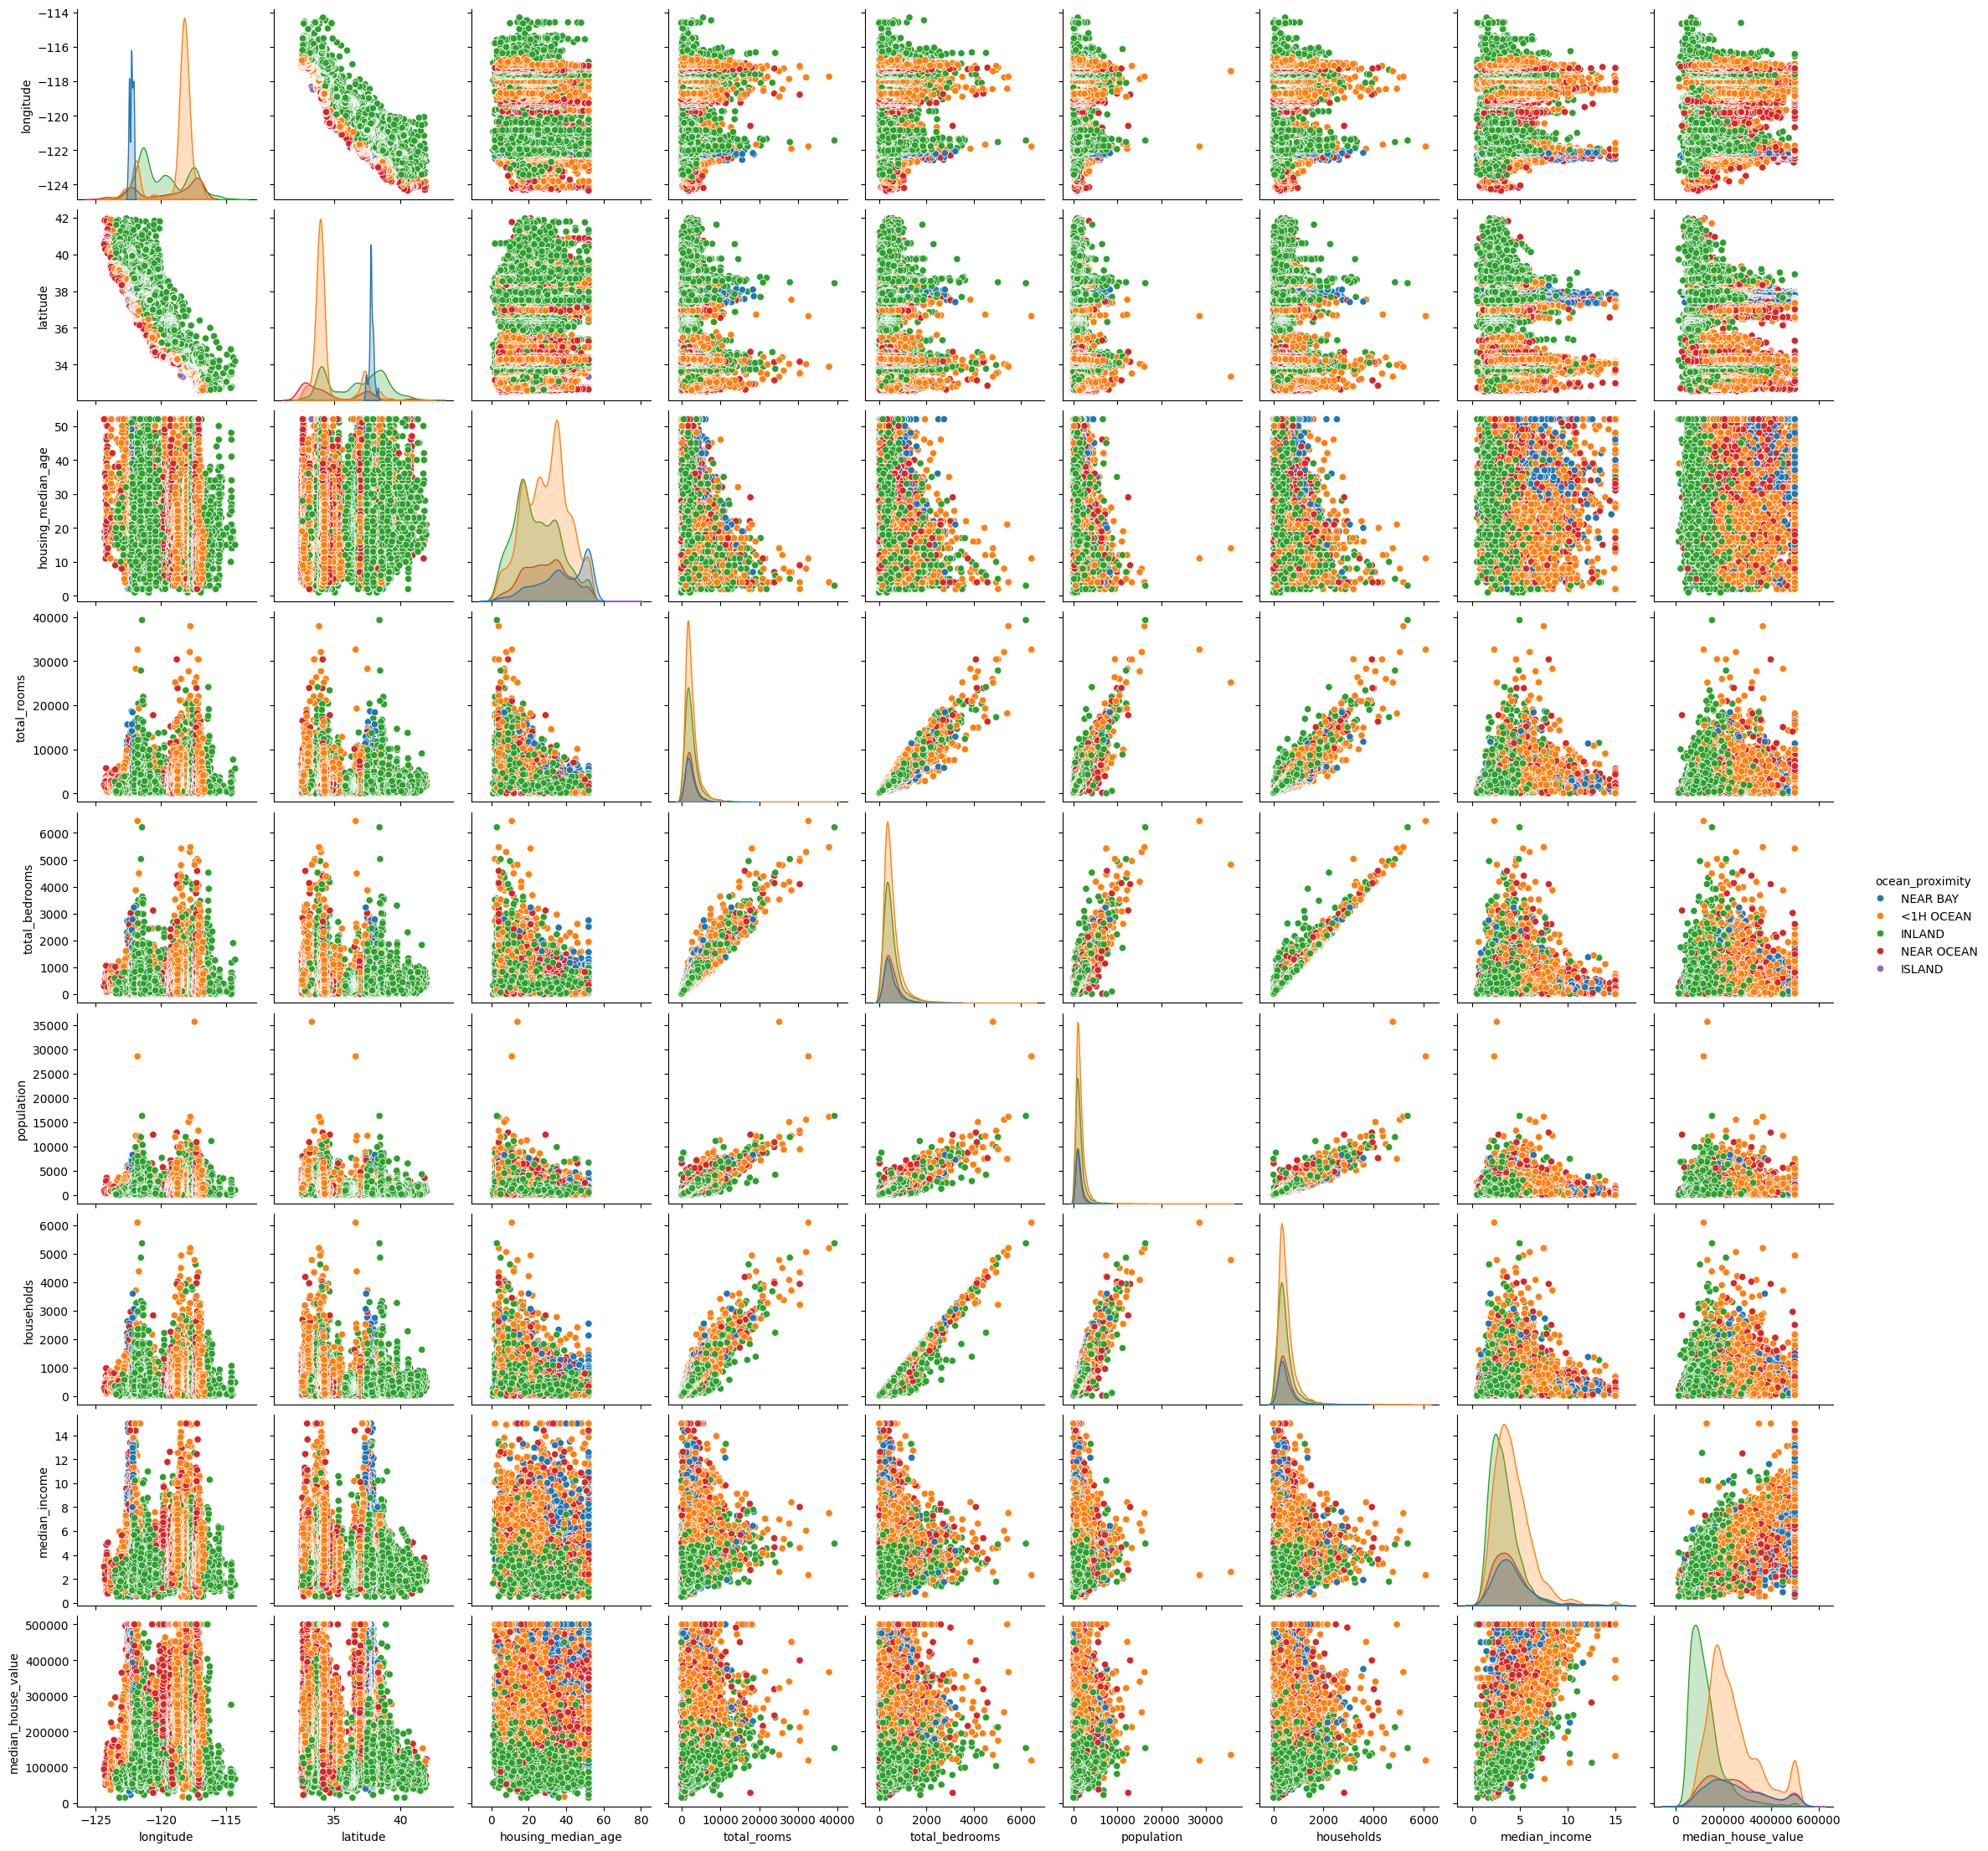

In [5]:
sns.pairplot(housing_data, hue='ocean_proximity')

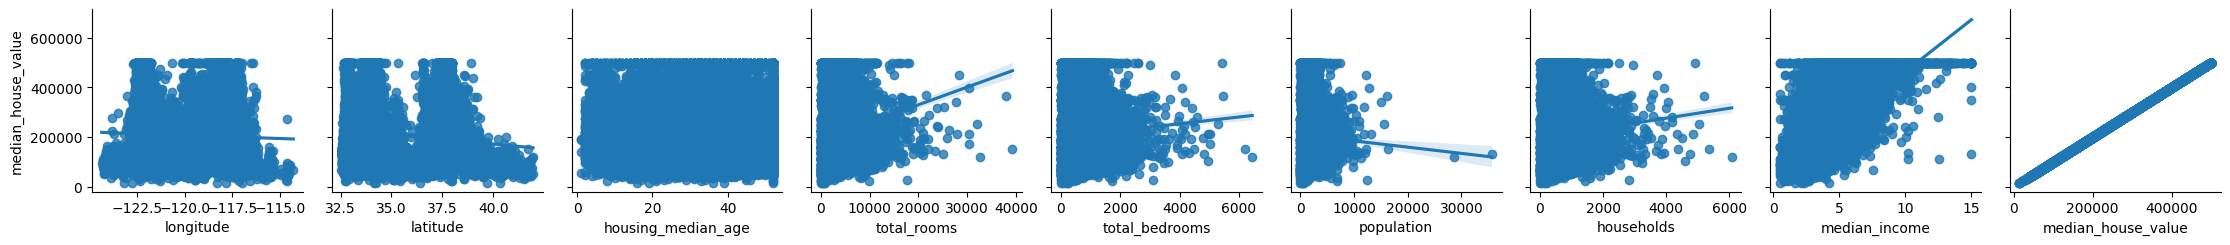

In [6]:
g = sns.PairGrid(housing_data, y_vars=['median_house_value'])
g.map(sns.regplot)

**I will try to create a multiple regression model to predict the median house value in California using the other data** 

## Target Model (using sklearn)

In [ ]:
from sklearn.linear_model import LinearRegression

X = housing_data.drop(columns=['median_house_value', 'ocean_proximity'])
y = housing_data['median_house_value']

model = LinearRegression()
model.fit(X, y)

model.coef_, model.intercept_

(array([-4.27301205e+04, -4.25097369e+04,  1.15790031e+03, -8.24972507e+00,
         1.13820707e+02, -3.83855780e+01,  4.77013513e+01,  4.02975217e+04]),
 -3585395.747892373)

## Create Model From Scratch

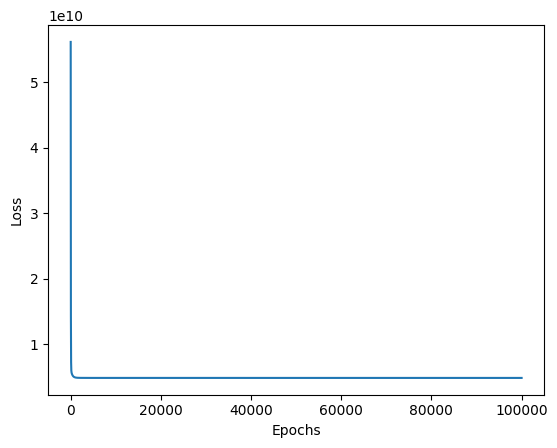

In [59]:
y = housing_data['median_house_value'].to_numpy()
X = housing_data.drop(columns=['median_house_value', 'ocean_proximity']).to_numpy()

def mse(y, y_pred):
    return np.mean((y_pred - y) ** 2)

def predict(X, w, b):
    return X @ w + b

def train(X, y, learning_rate=0.01, epochs=100000):

    #standardize so gradients will not tend to infinity
    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0)
    X_scaled = (X - X_mean) / X_std

    w = np.array([0, 0, 0, 0, 0, 0, 0, 0])
    b = 0

    n = len(y)

    losses = []

    for epoch in range(epochs):
        y_pred = predict(X_scaled, w, b)
        
        loss = mse(y, y_pred)
        losses.append(loss)

        dw = (2/n) * (X_scaled.T @ (y_pred - y))
        db = (2/n) * np.sum(y_pred - y)

        w = w - learning_rate * dw
        b = b - learning_rate * db

    sns.lineplot(losses).set(xlabel='Epochs', ylabel='Loss')

    # find actual w, b -- i.e., reverse the standardization
    b = b - np.sum(w * X_mean / X_std)
    w = w / X_std

    return w, b

w, b = train(X, y)

In [60]:
w, b

(array([-4.27301205e+04, -4.25097369e+04,  1.15790031e+03, -8.24972507e+00,
         1.13820707e+02, -3.83855780e+01,  4.77013513e+01,  4.02975217e+04]),
 -3585395.747892284)

**sklearn result:**

(array([-4.27301205e+04, -4.25097369e+04,  1.15790031e+03, -8.24972507e+00,
         1.13820707e+02, -3.83855780e+01,  4.77013513e+01,  4.02975217e+04]),
 -3585395.747892373)


**my result:**

(array([-4.27301205e+04, -4.25097369e+04,  1.15790031e+03, -8.24972507e+00,
         1.13820707e+02, -3.83855780e+01,  4.77013513e+01,  4.02975217e+04]),
 -3585395.747892284)